In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = load_iris()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(df)

print("Data scaled successfully!")

Data scaled successfully!


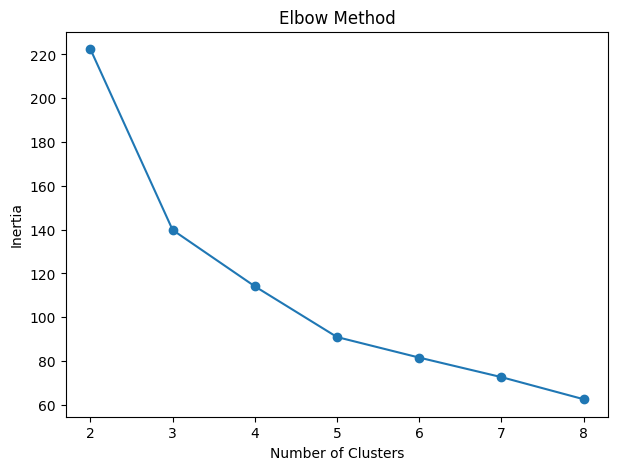

In [6]:
inertia = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X)

print("K-Means clustering completed!")
print("Silhouette Score:", silhouette_score(X, kmeans_labels))

K-Means clustering completed!
Silhouette Score: 0.45994823920518635


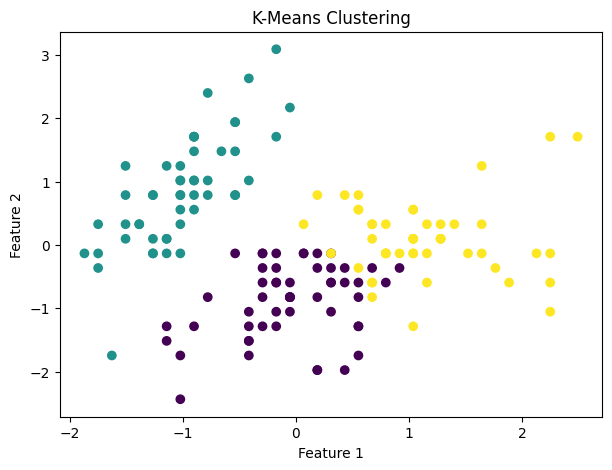

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

In [9]:
hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(X)

print("Hierarchical clustering completed!")
print(
    "Silhouette Score:",
    silhouette_score(X, hierarchical_labels)
)

Hierarchical clustering completed!
Silhouette Score: 0.4466890410285909


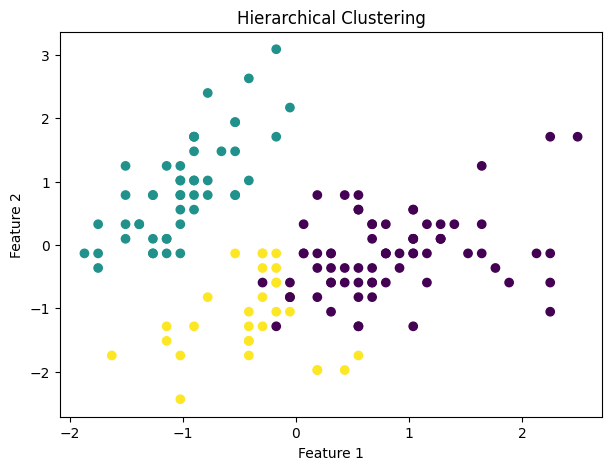

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=hierarchical_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering")
plt.show()

In [11]:
kmeans_score = silhouette_score(X, kmeans_labels)
hierarchical_score = silhouette_score(X, hierarchical_labels)

results = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score
    ]
})

results.round(4)

,Model,Silhouette Score
0,K-Means,0.4599
1,Hierarchical Clustering,0.4467


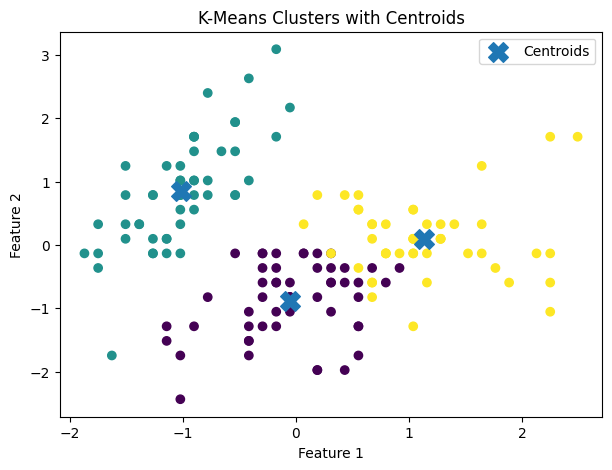

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clusters with Centroids")
plt.legend()
plt.show()

In [13]:
print("Final Model Comparison")
print("----------------------")

print("K-Means Silhouette Score:",
      round(kmeans_score, 4))

print("Hierarchical Clustering Silhouette Score:",
      round(hierarchical_score, 4))

Final Model Comparison
----------------------
K-Means Silhouette Score: 0.4599
Hierarchical Clustering Silhouette Score: 0.4467
